In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "benchmark").is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark.examples.diffusion.config import BASE_DIR, RESULT_DIR, TrainingConfig
from benchmark.examples.diffusion.results.summary_dimension_comparison import (
    MODEL_SETS,
    NO_MMD_SUMMARY_SPECS,
    display_gold_pmp_lowess_grid,
    display_summary_dimension_comparison,
    generate_calibrated_gold_pmp_lowess_grid,
    run_calibrated_comparison_pipeline,
)

from benchmark.examples.diffusion.calibration.thresholds import (
    calculate_and_save_thresholds,
)


INFO:bayesflow:Using backend 'tensorflow'


In [2]:
METRICS = ("density",)
# Configure x globally and toggle symlog independently for each y result type.
XSCALE = "symlog"
USE_SYMLOG_Y = {
    "posterior_mmd": False,
    "logml": True,
    "pmp": False,
}
YSCALE = {
    result_type: "symlog" if use_symlog else "linear"
    for result_type, use_symlog in USE_SYMLOG_Y.items()
}
LOGML_Y_SYMLOG_LINTHRESH = 0.1
# LOESS controls for the combined simulated-and-empirical figures.
SHOW_LOESS = True
# Empirical-only LOESS uses only empirical observations.
SHOW_EMPIRICAL_ONLY_LOESS = True
INCLUDE_EMPIRICAL_IN_LOESS = True
LOESS_FRAC_BY_FIT_SOURCE = {
    "simulated_only": 1.0,
    "simulated_and_empirical": 1.0,
}
NORMALIZE_METRICS = False  # Applies to posterior MMD/logML only; PMP always remains raw.
EXPECTED_CALIBRATION_DATASETS = 100
CALIBRATION_SUMMARY_MULTIPLIERS = (1, 2, 4)

RERUN_SUFFIX = "noMMD_rerun1"
RERUN_VARIANT = "without_mmd_rerun1"
RERUN_SUMMARY_SPECS = tuple(
    (
        label,
        TrainingConfig(
            summary_multiplier=config.summary_multiplier,
            summary_base_distribution=None,
            run_suffix=RERUN_SUFFIX,
        ),
    )
    for label, config in NO_MMD_SUMMARY_SPECS
    if config.summary_multiplier in CALIBRATION_SUMMARY_MULTIPLIERS
)

OUTPUT_ROOT = (
    RESULT_DIR / "plots" / "summary_diagnostics_noMMD_rerun1_calibrated_thresholds"
)
OVERLAY_OUTPUT_ROOT = (
    RESULT_DIR / "plots" / "diagnostic_overlays_calibrated_noMMD_rerun1"
)
THRESHOLD_PATH = (
    BASE_DIR / "calibration_outputs_100_noMMD_rerun1" / "thresholds.csv"
)


In [3]:
# Recompute thresholds from the merged 100-dataset calibration metrics.
POSTERIOR_MMD_QUANTILE = 0.95
SIGNED_ERROR_COVERAGE = 0.90
CALIBRATION_ROOT = THRESHOLD_PATH.parent
THRESHOLD_RESULTS_PATH = CALIBRATION_ROOT / "per_dataset_results.csv"

calibration_thresholds, _ = calculate_and_save_thresholds(
    input_path=CALIBRATION_ROOT / "per_dataset_metrics.csv",
    thresholds_path=THRESHOLD_PATH,
    results_path=THRESHOLD_RESULTS_PATH,
    quantile=POSTERIOR_MMD_QUANTILE,
    signed_error_coverage=SIGNED_ERROR_COVERAGE,
)

posterior_rows = calibration_thresholds["metric"].eq("posterior_mmd")
signed_error_rows = calibration_thresholds["metric"].isin(
    ["signed_logml_error", "signed_pmp_error"]
)
assert calibration_thresholds.loc[posterior_rows, "lower_quantile"].eq(0.0).all()
assert calibration_thresholds.loc[posterior_rows, "upper_quantile"].eq(0.95).all()
assert (
    calibration_thresholds.loc[signed_error_rows, "lower_quantile"]
    .sub(0.05)
    .abs()
    .lt(1e-12)
    .all()
)
assert calibration_thresholds.loc[signed_error_rows, "upper_quantile"].eq(0.95).all()


expected_n_values = calibration_thresholds["metric"].map(
    {
        "posterior_mmd": EXPECTED_CALIBRATION_DATASETS,
        "signed_logml_error": EXPECTED_CALIBRATION_DATASETS,
        "signed_pmp_error": 4 * EXPECTED_CALIBRATION_DATASETS,
    }
)
assert calibration_thresholds["n_values"].eq(expected_n_values).all(), (
    "Threshold input is not the expected merged 100-dataset calibration set"
)

print(f"100-dataset thresholds refreshed: {THRESHOLD_PATH}")


100-dataset thresholds refreshed: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/calibration_outputs_100_noMMD_rerun1/thresholds.csv


LOESS lines: shown; fit source: simulated + empirical; frac: 1.0
all_density /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_diagnostics_noMMD_rerun1_calibrated_thresholds/all/density


## Simulated and empirical datasets

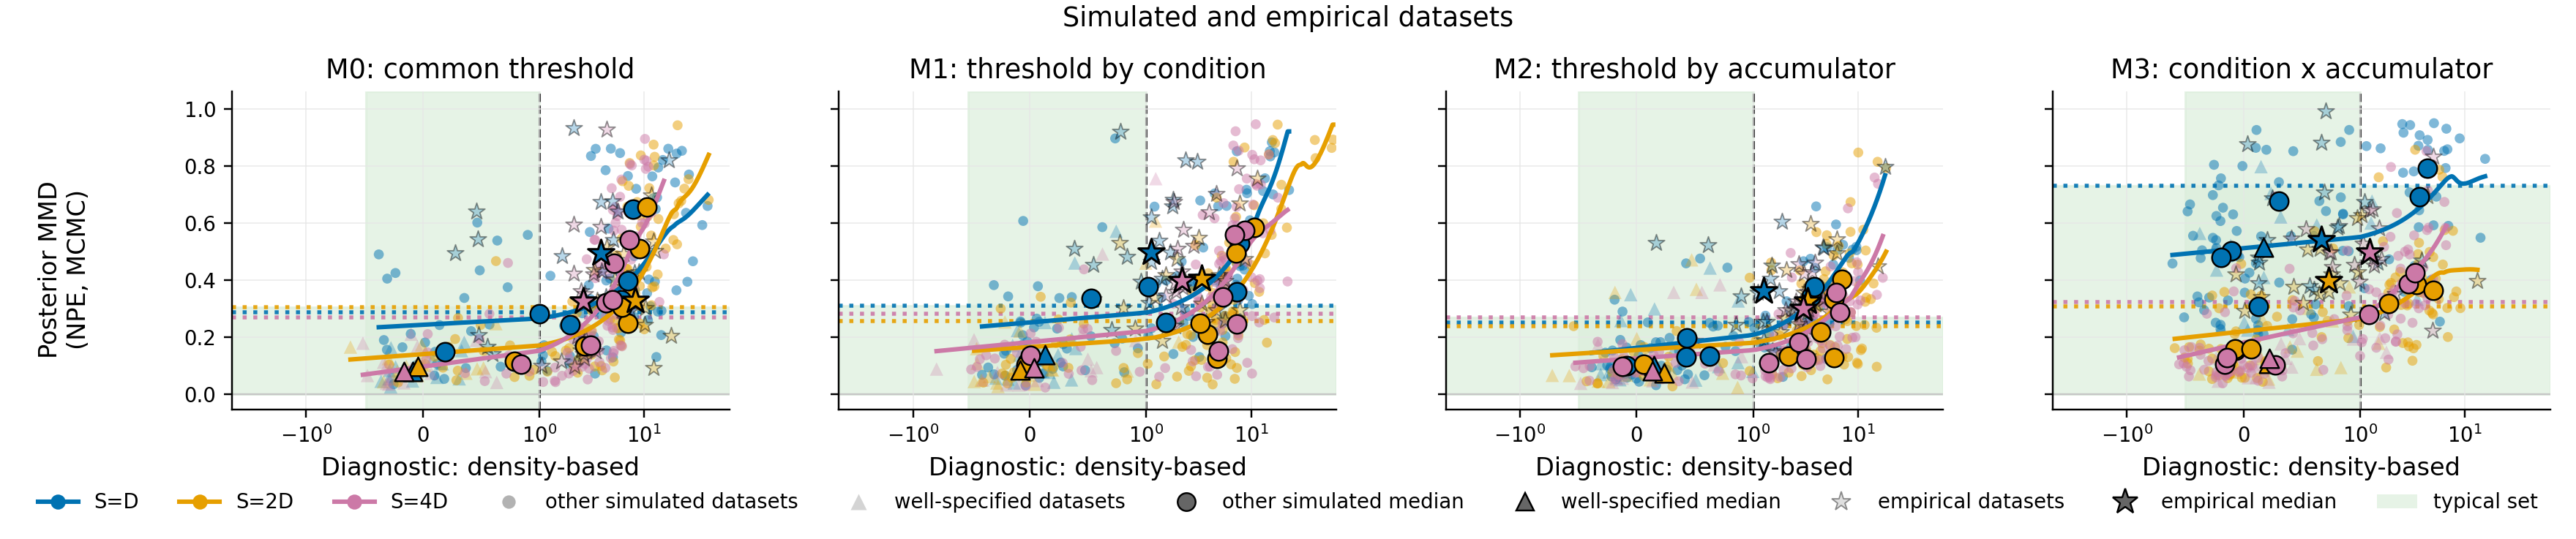

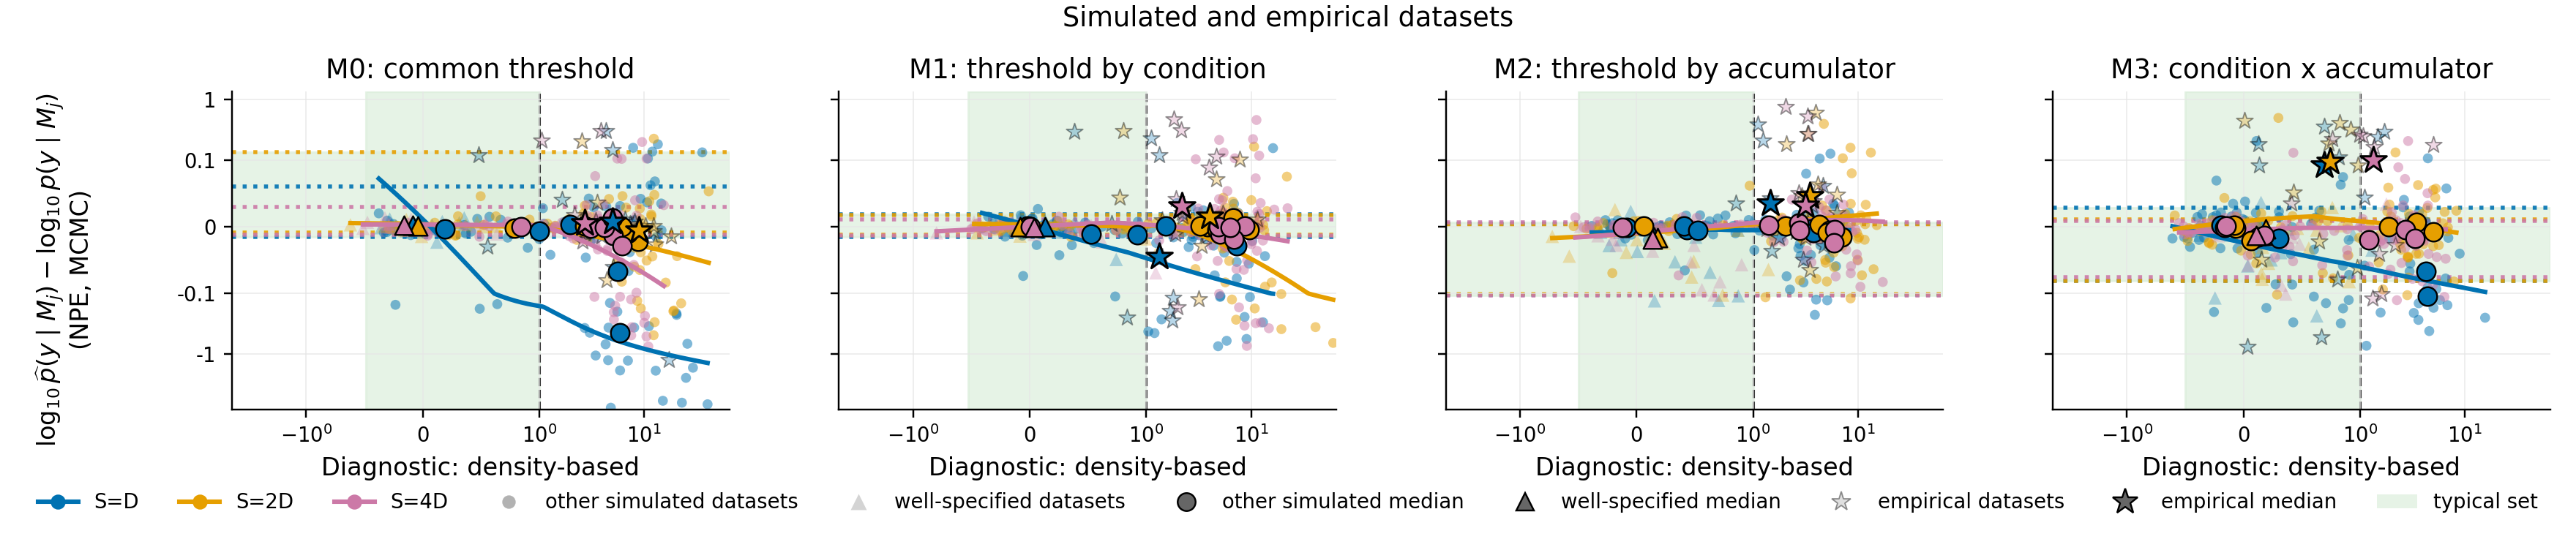

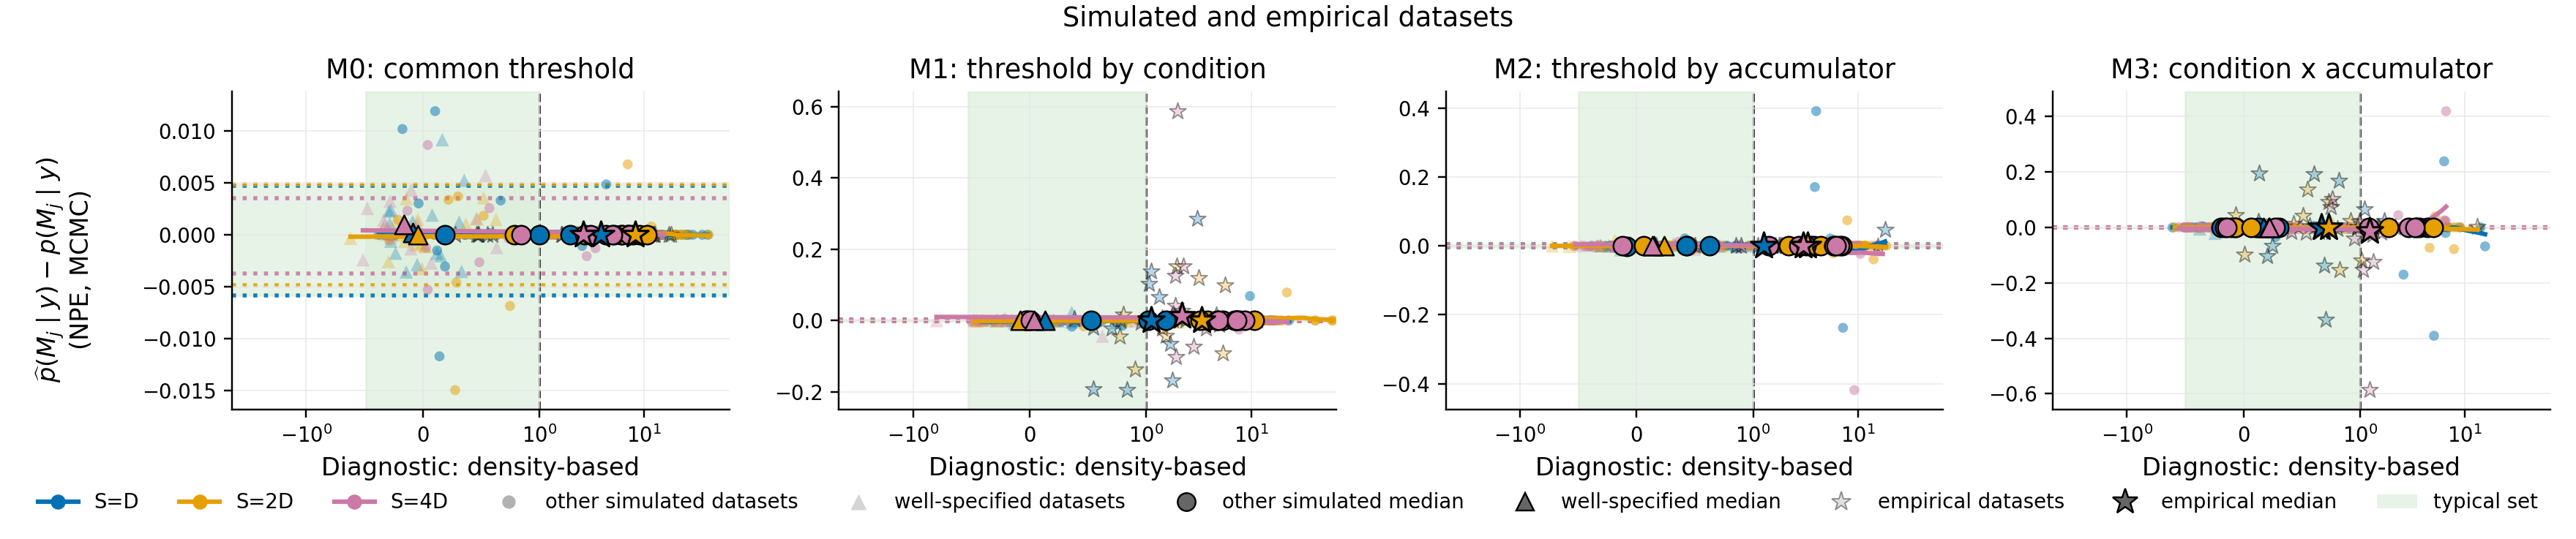

## Empirical only datasets

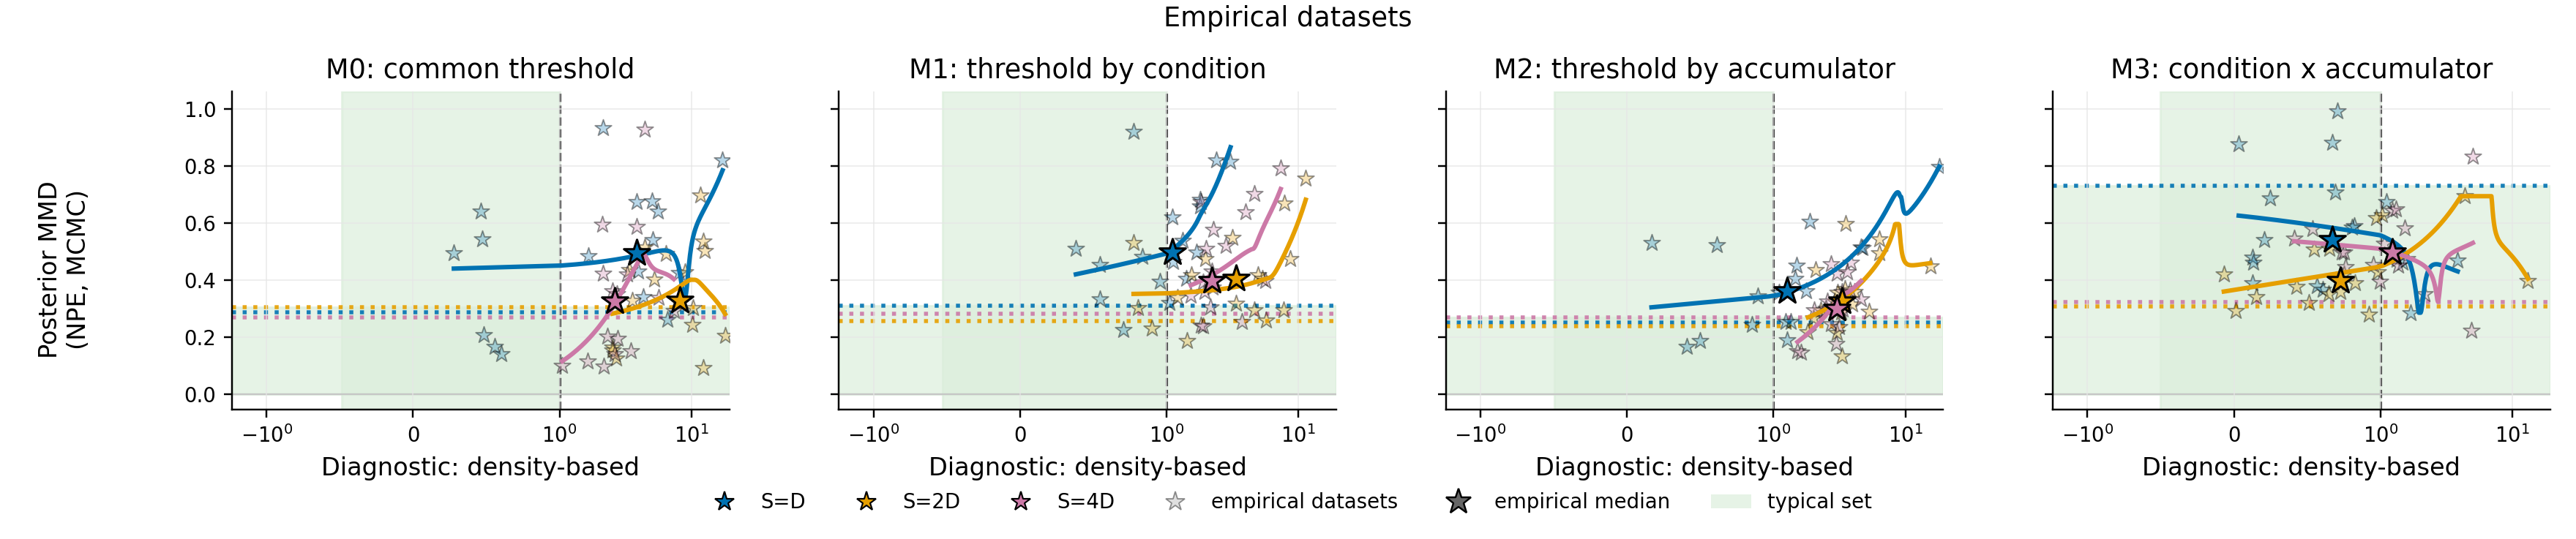

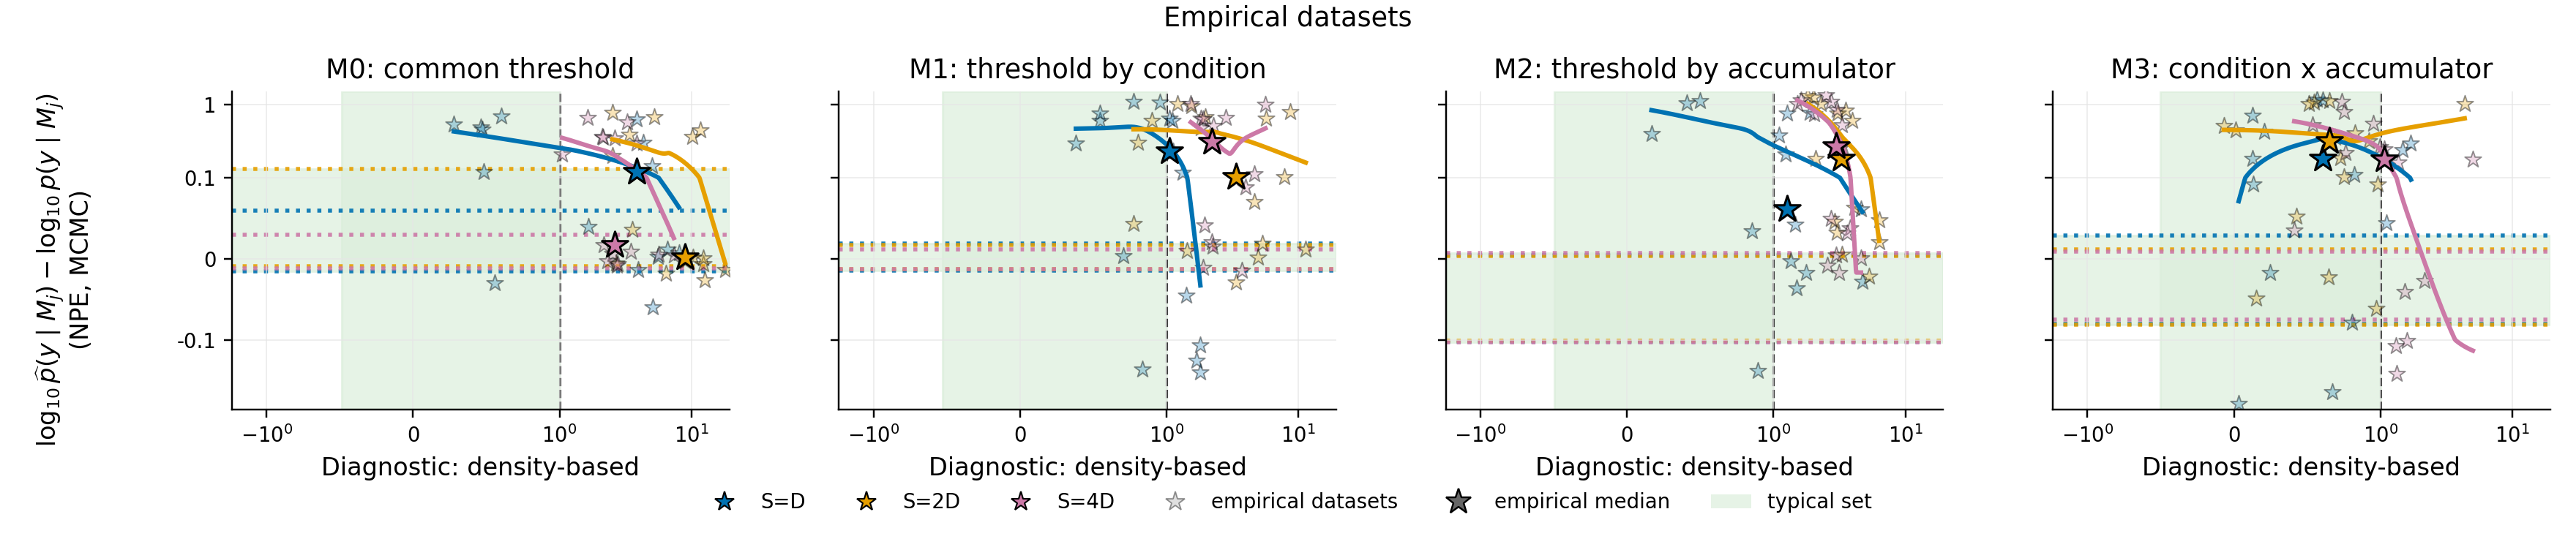

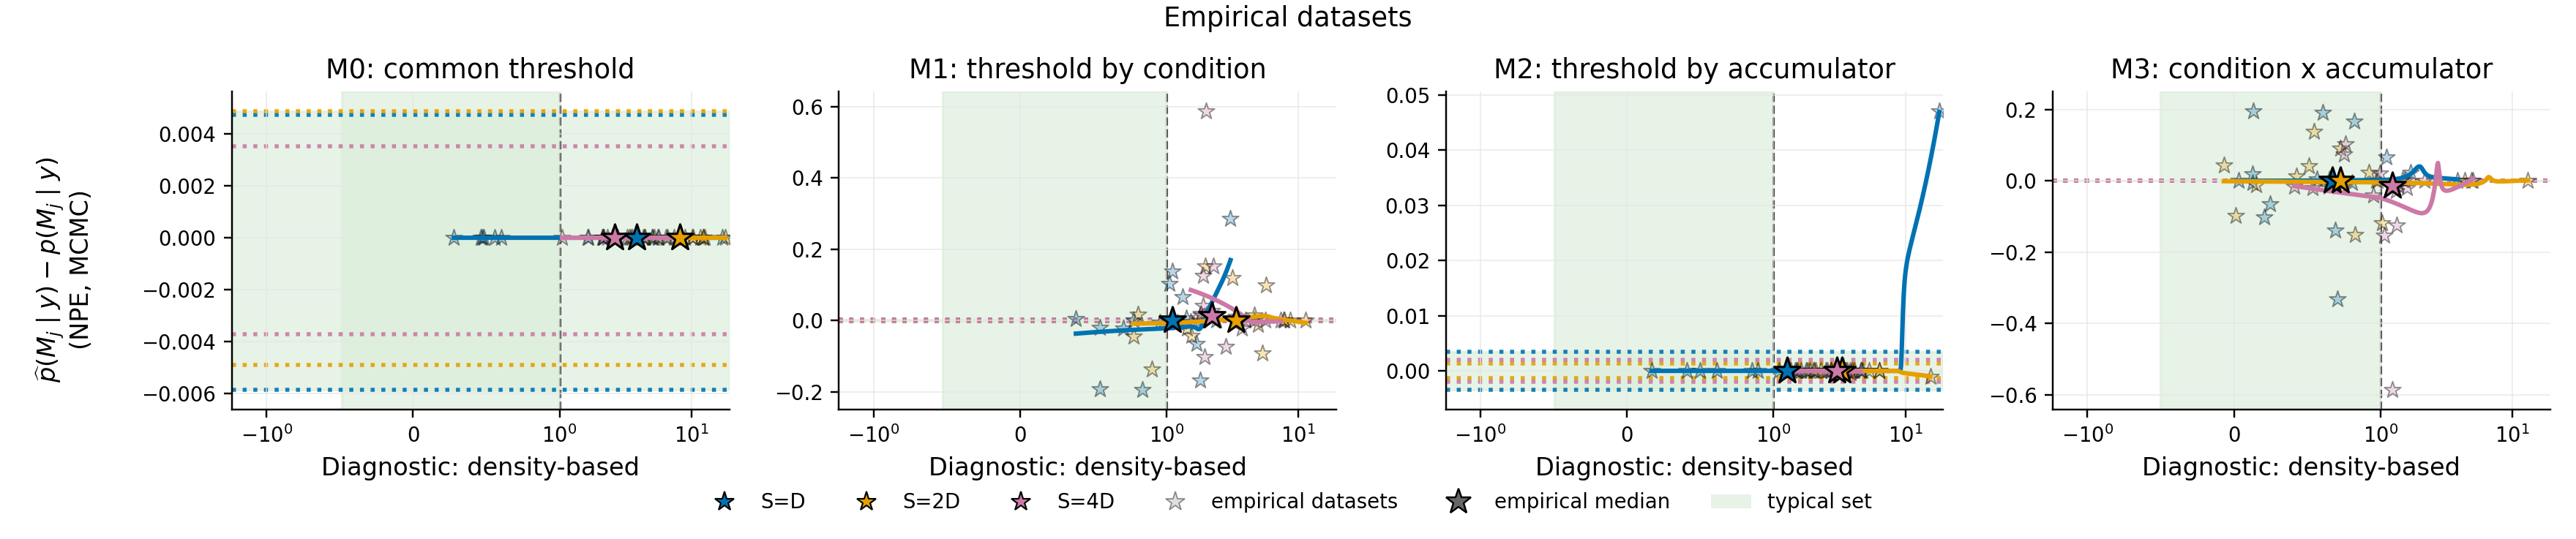

m1_m3_density /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_diagnostics_noMMD_rerun1_calibrated_thresholds/m1_m3/density


## Simulated and empirical datasets

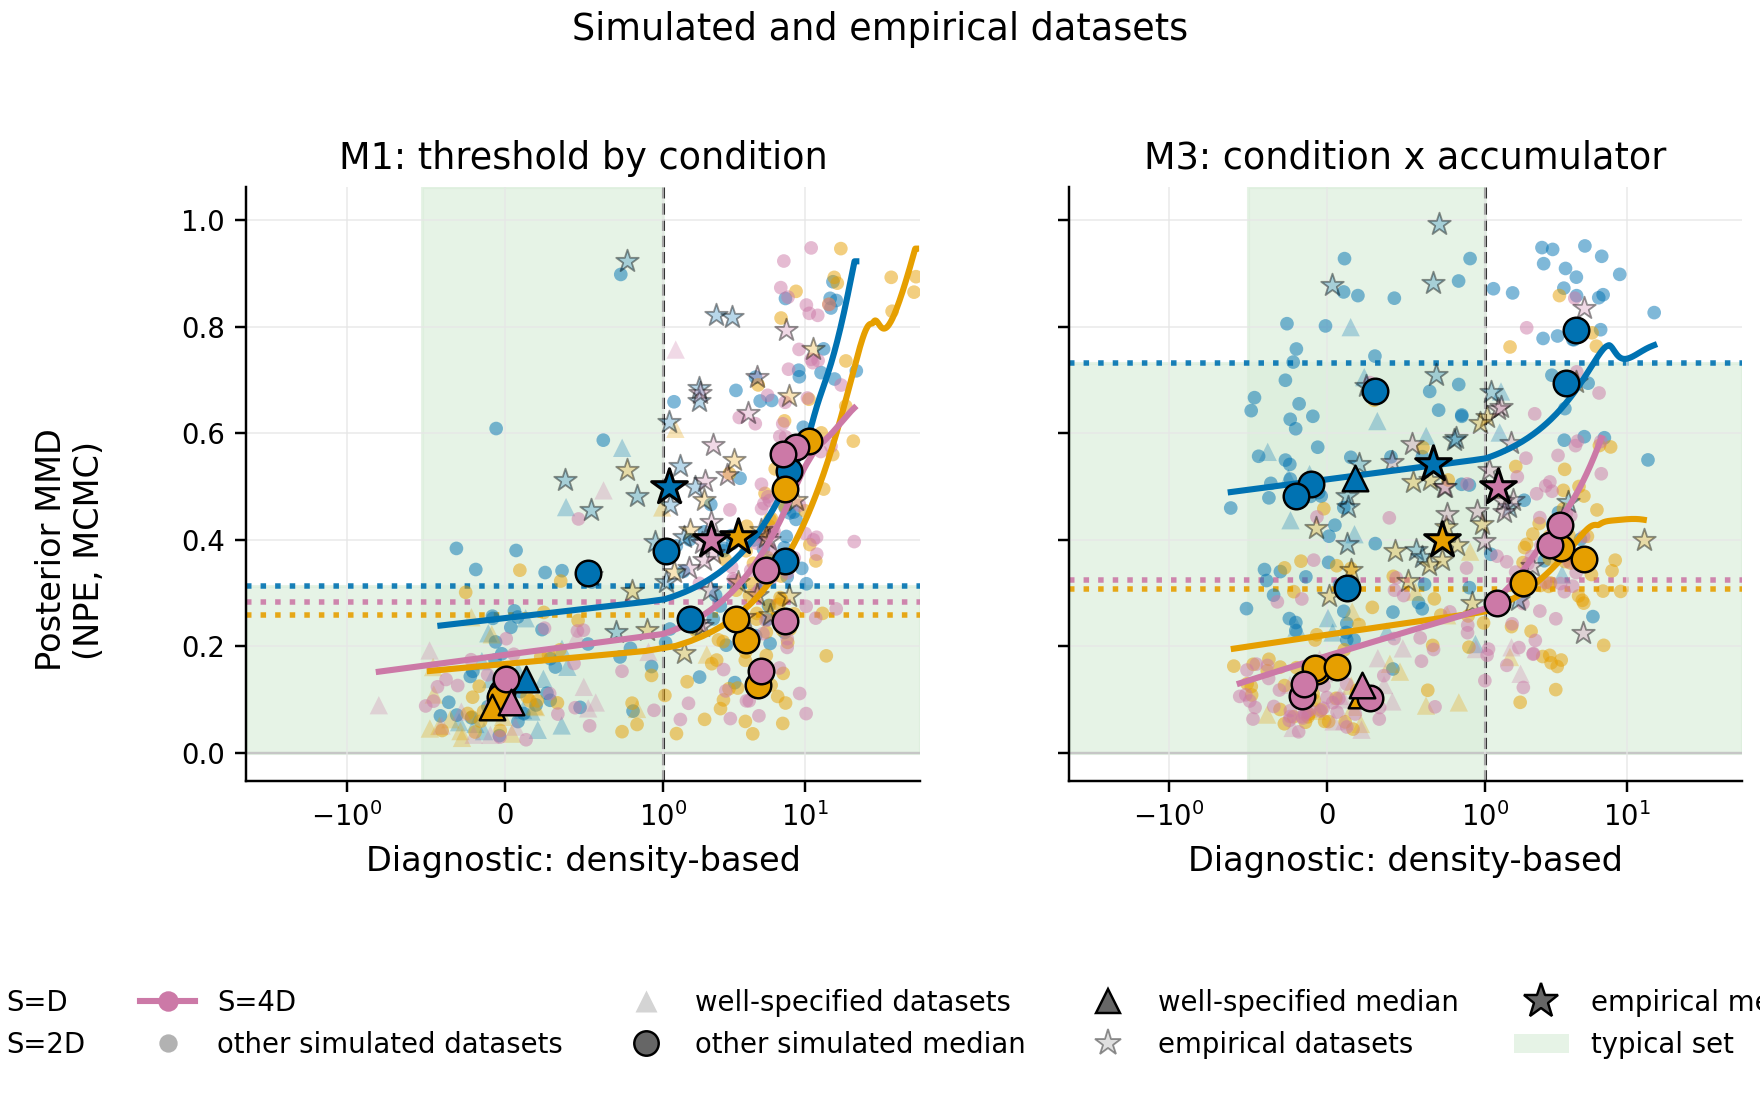

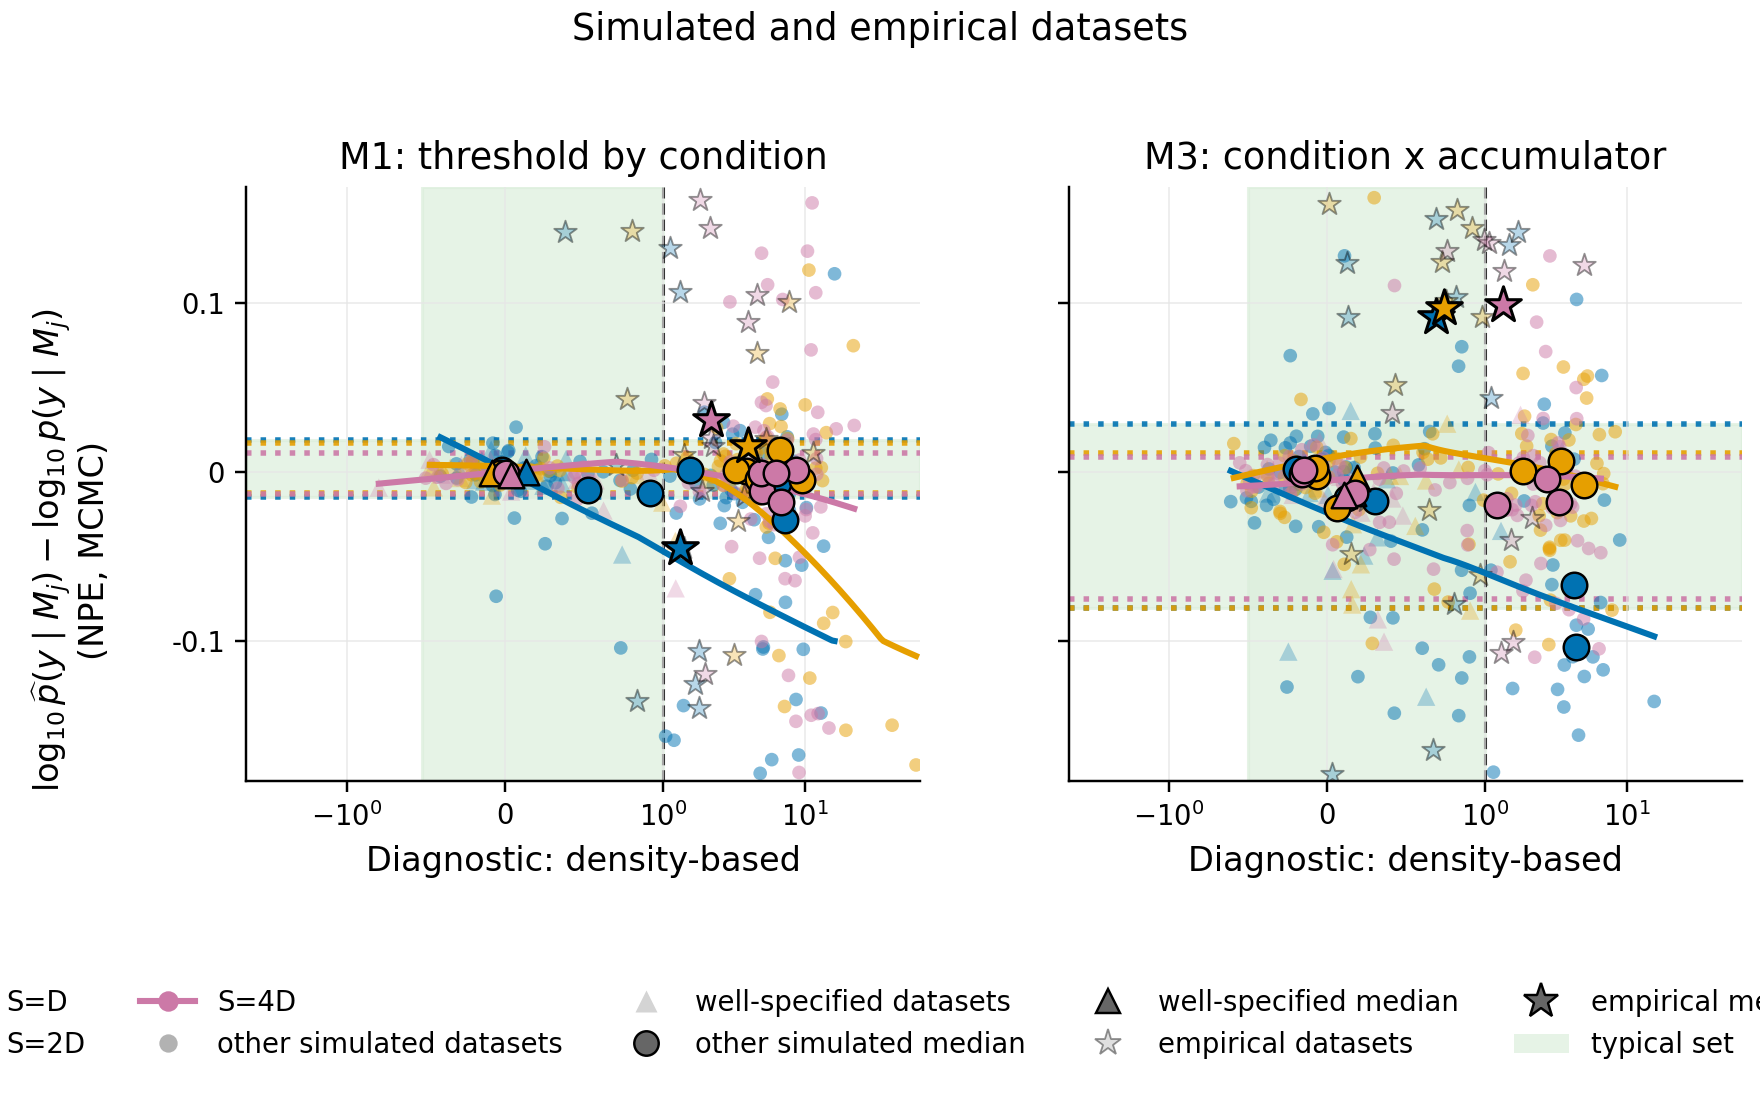

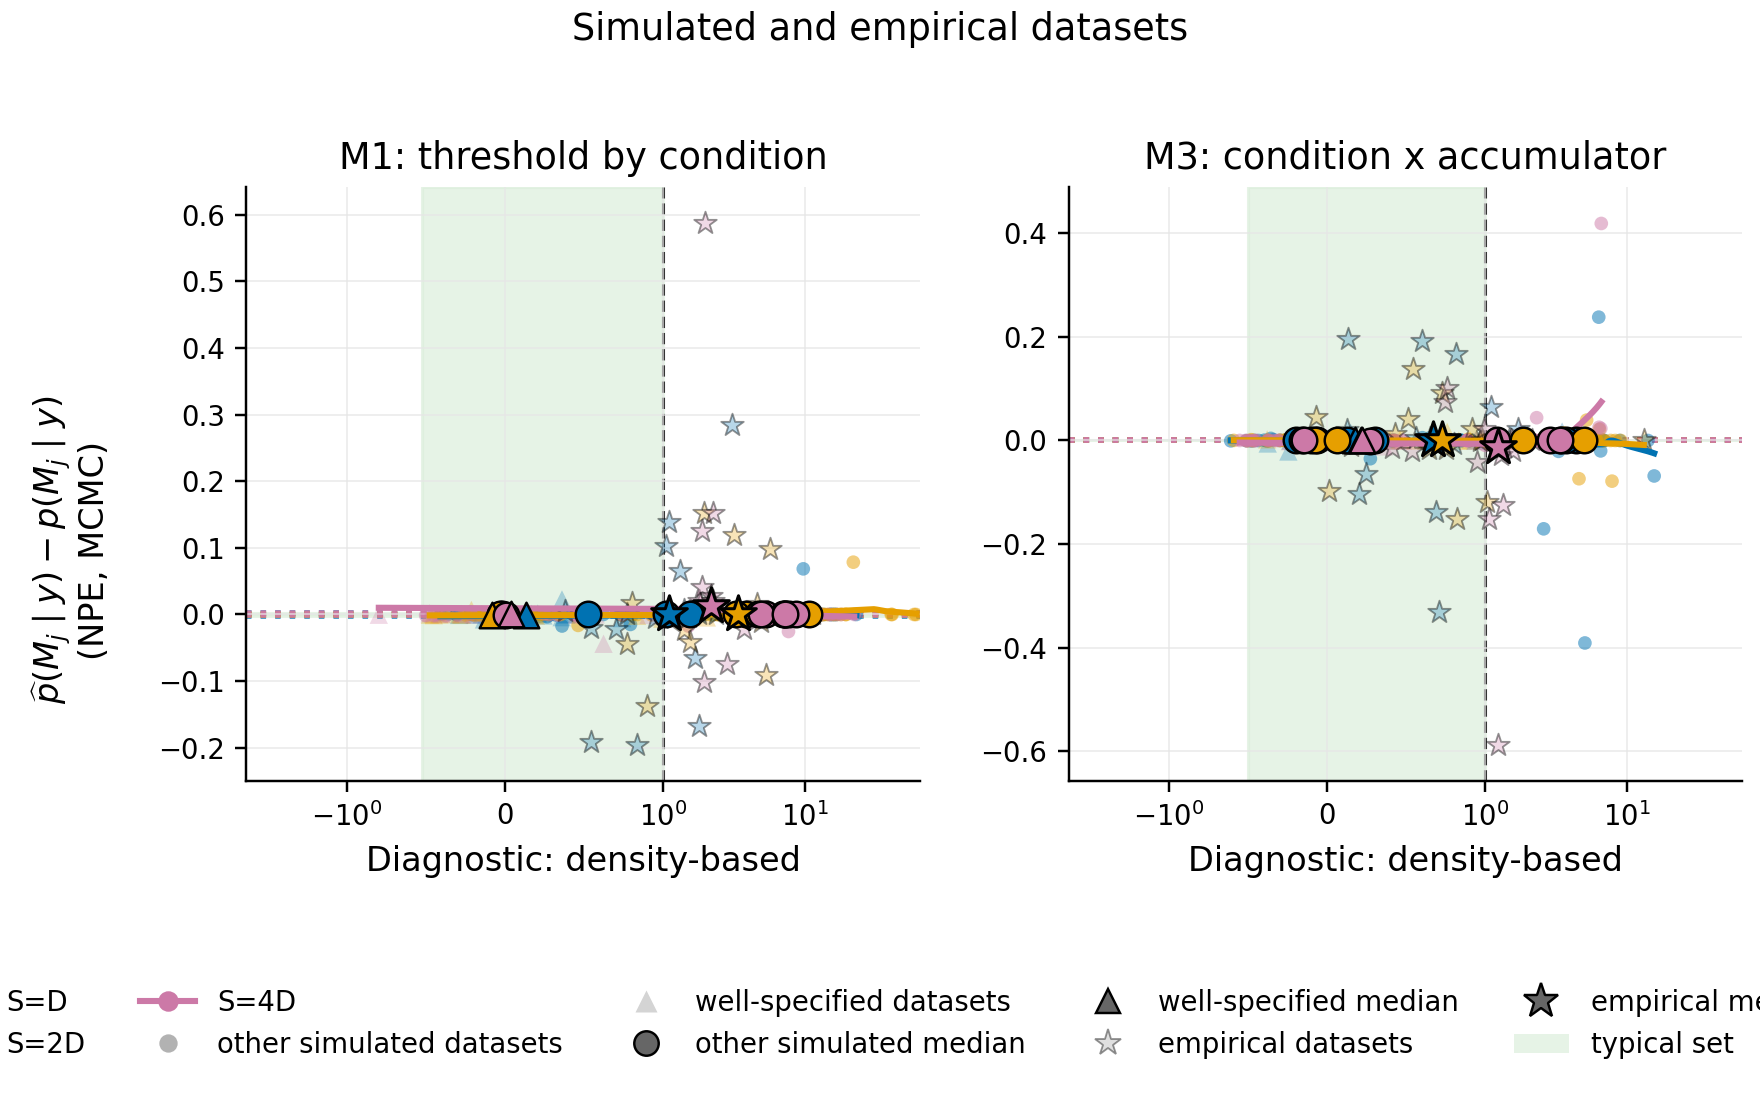

## Empirical only datasets

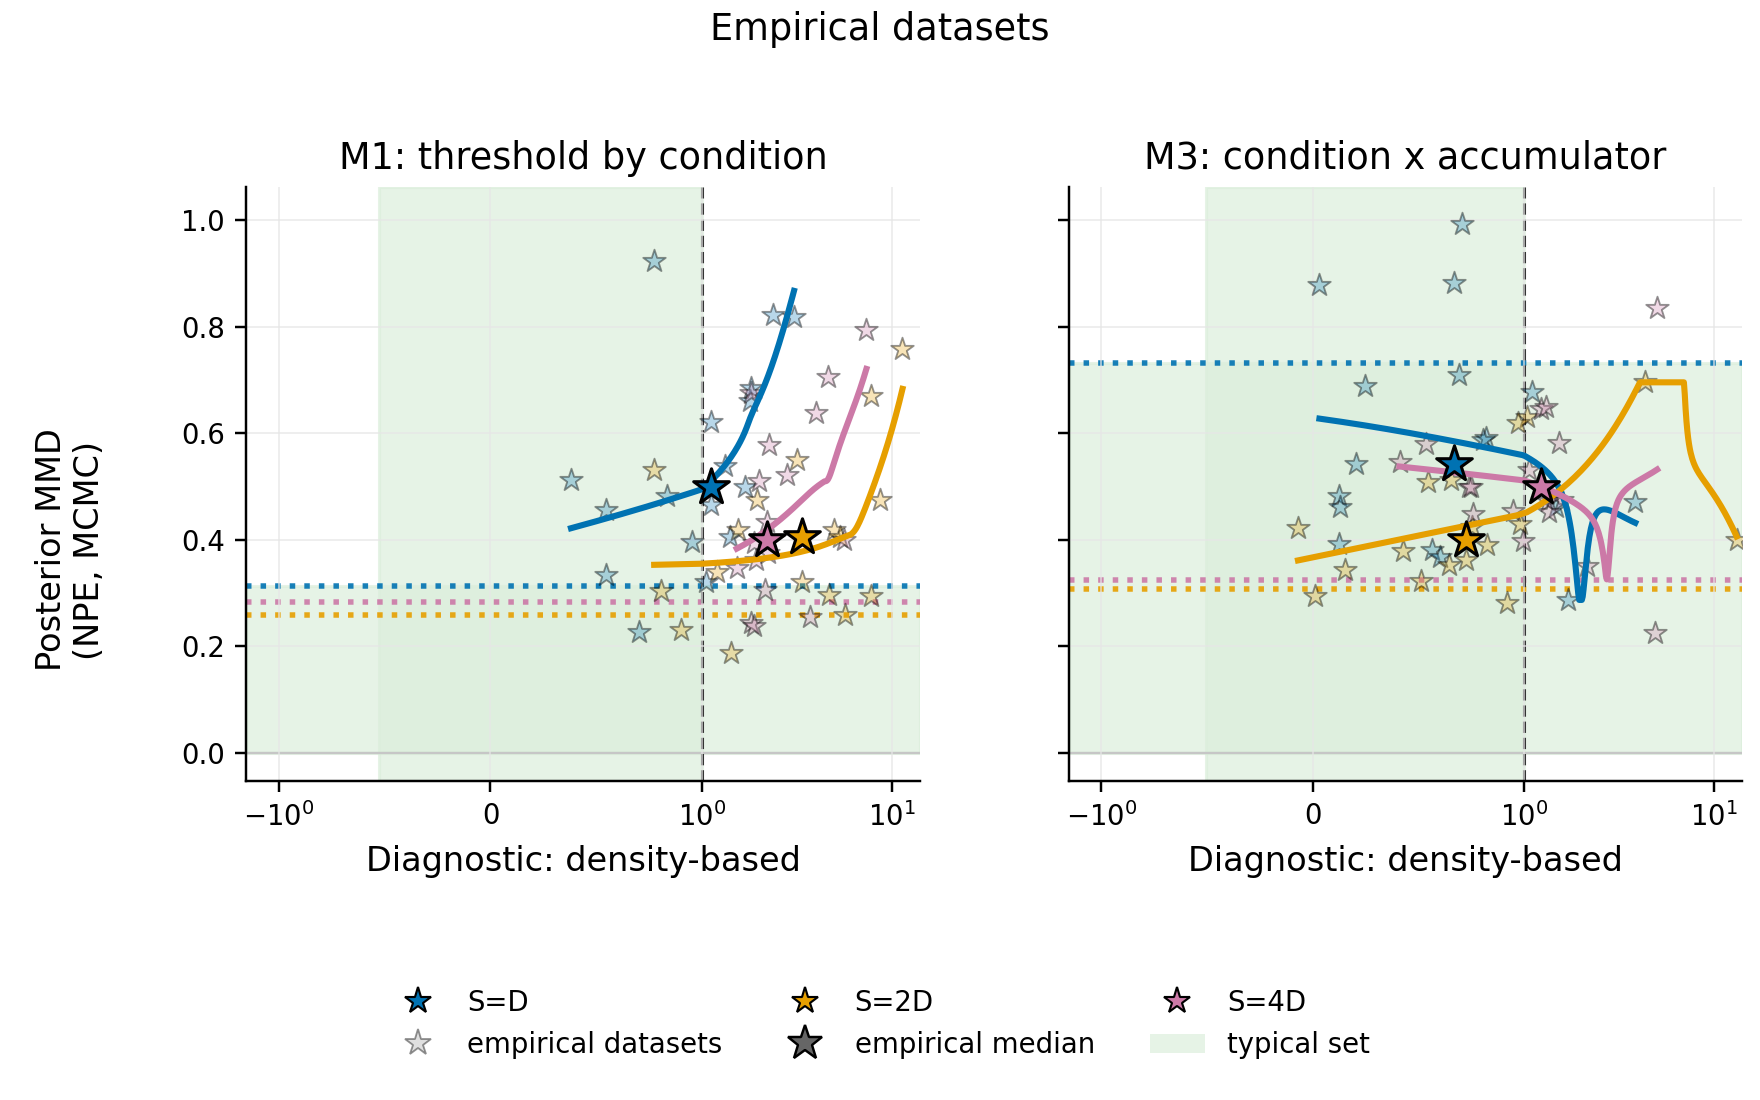

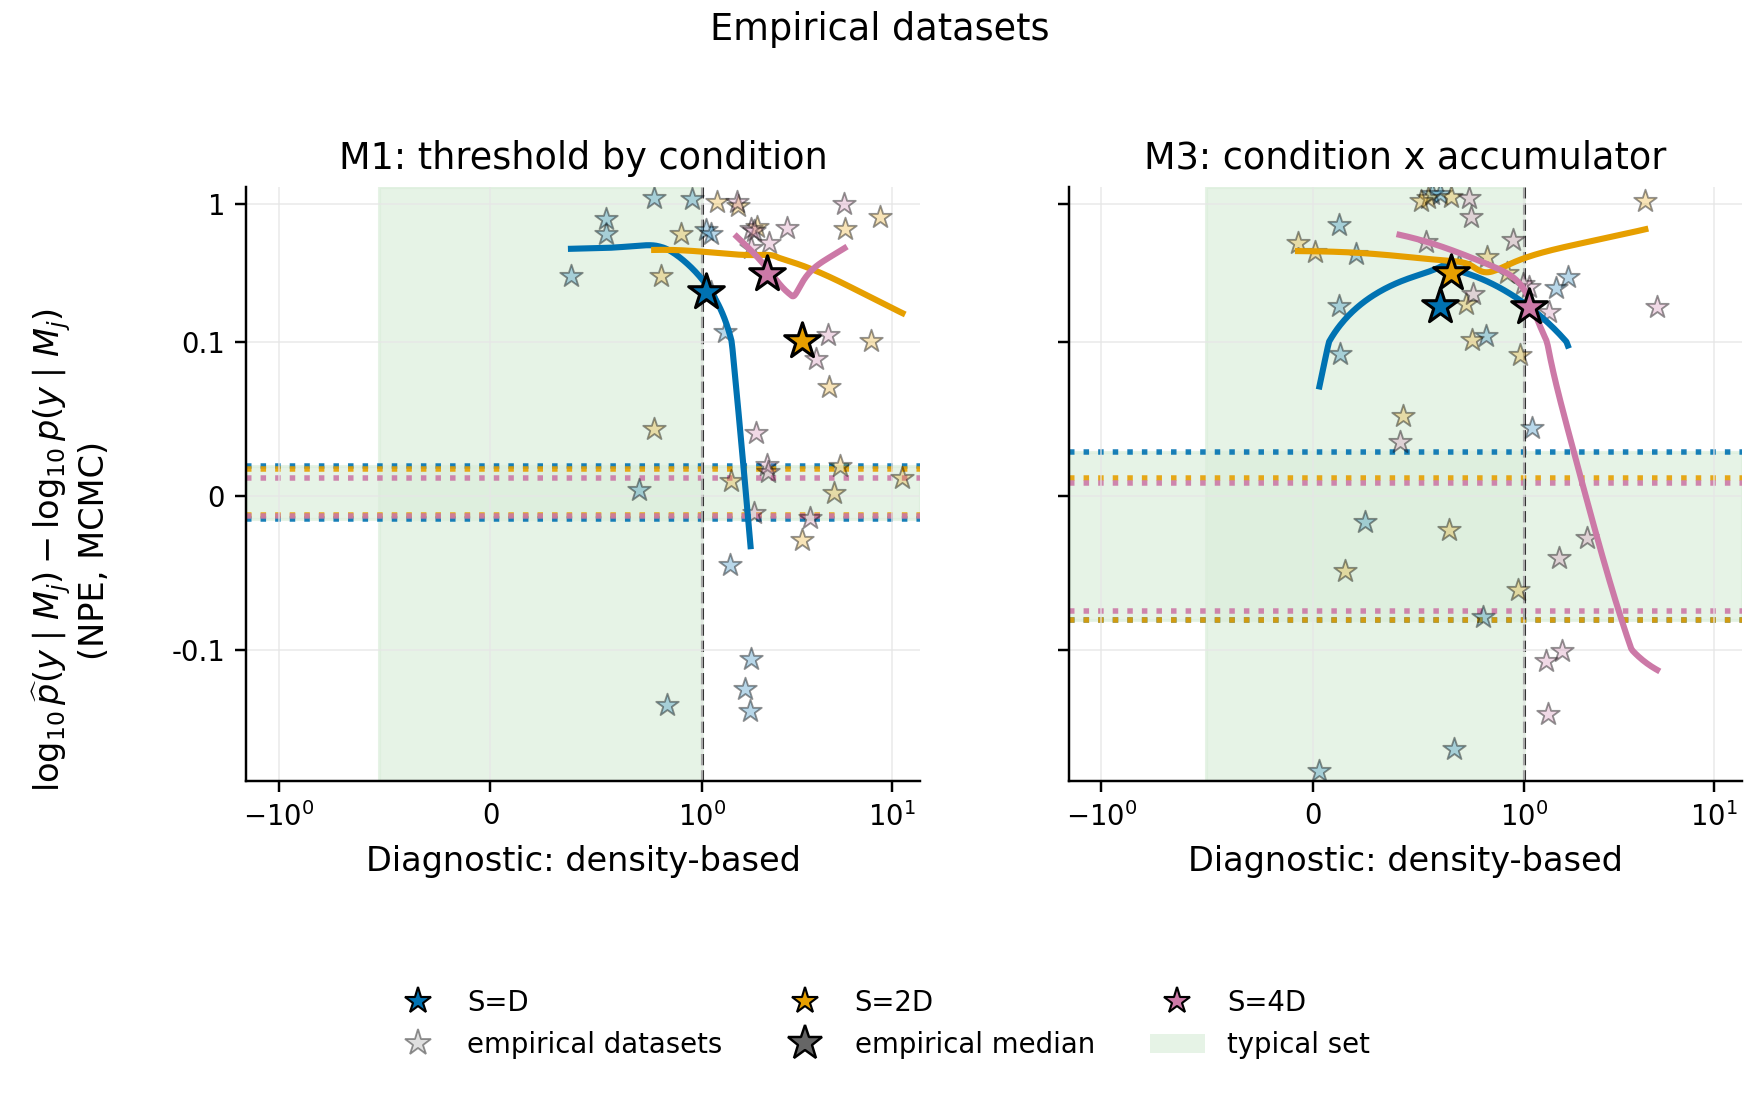

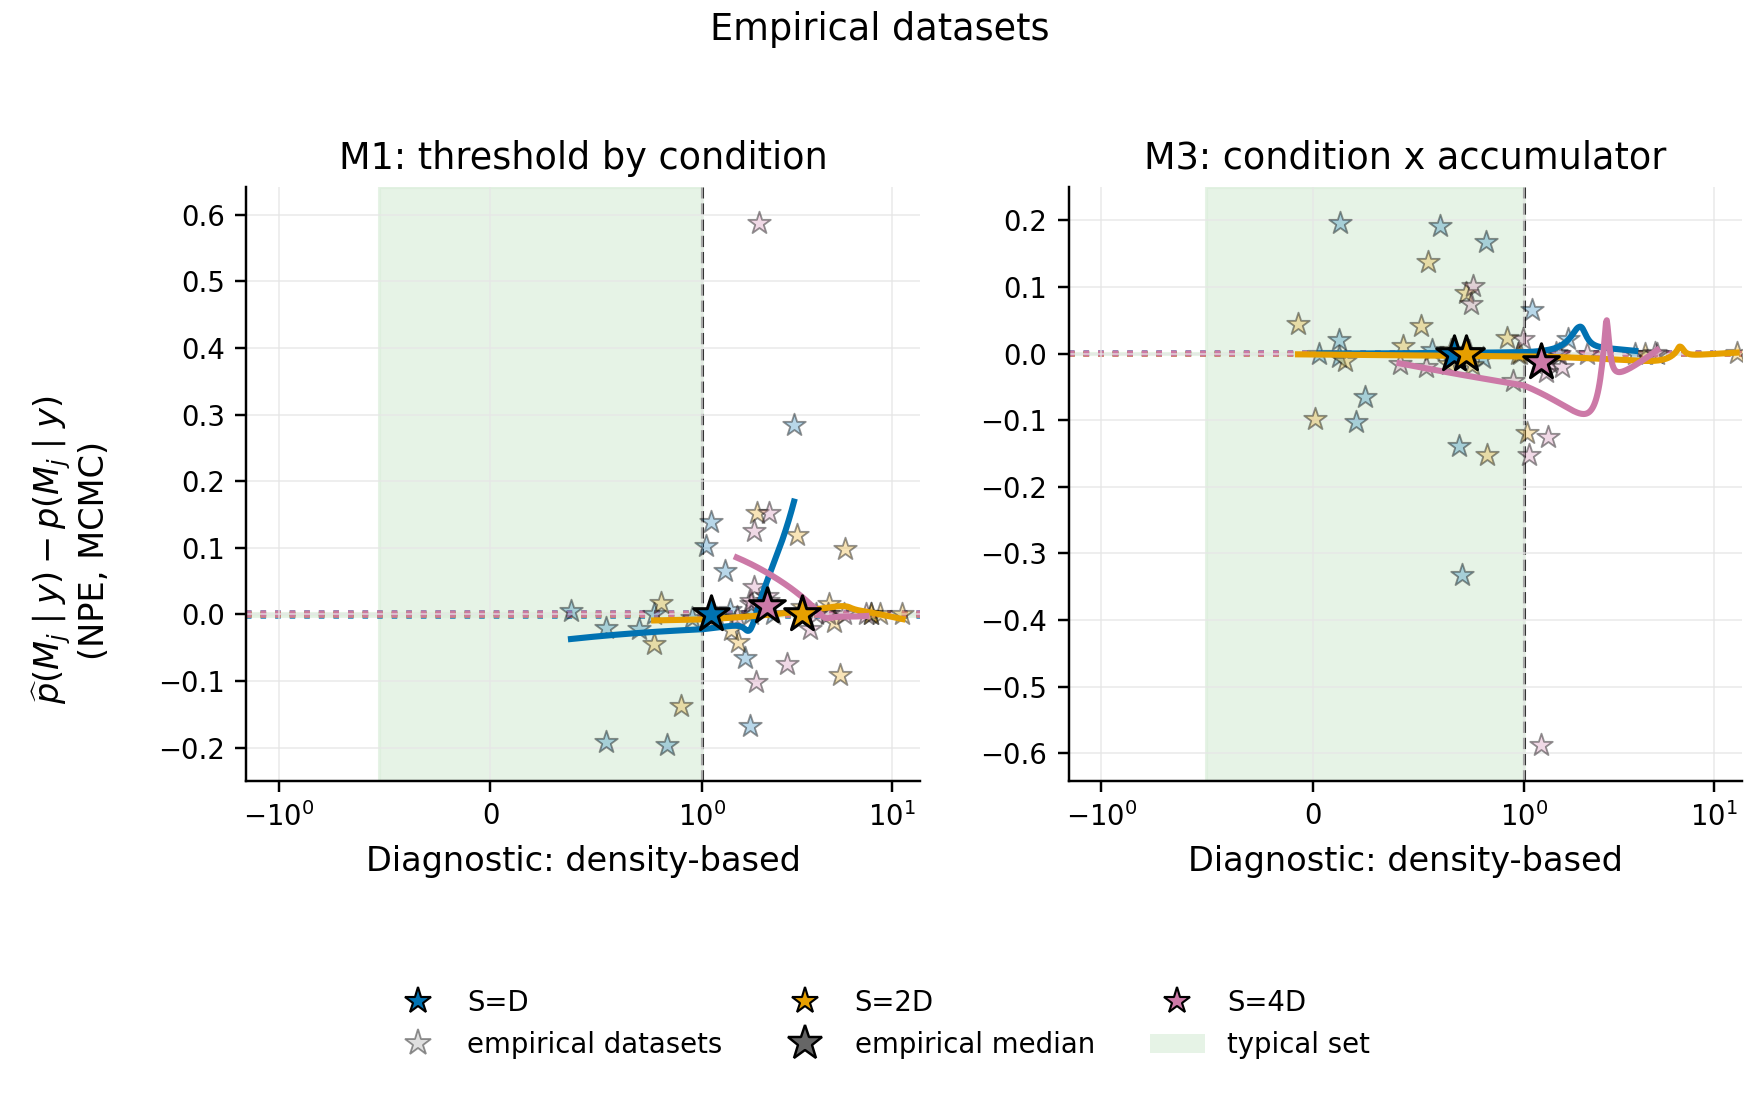

## Empirical PMP error vs. diagnostic $\rho$

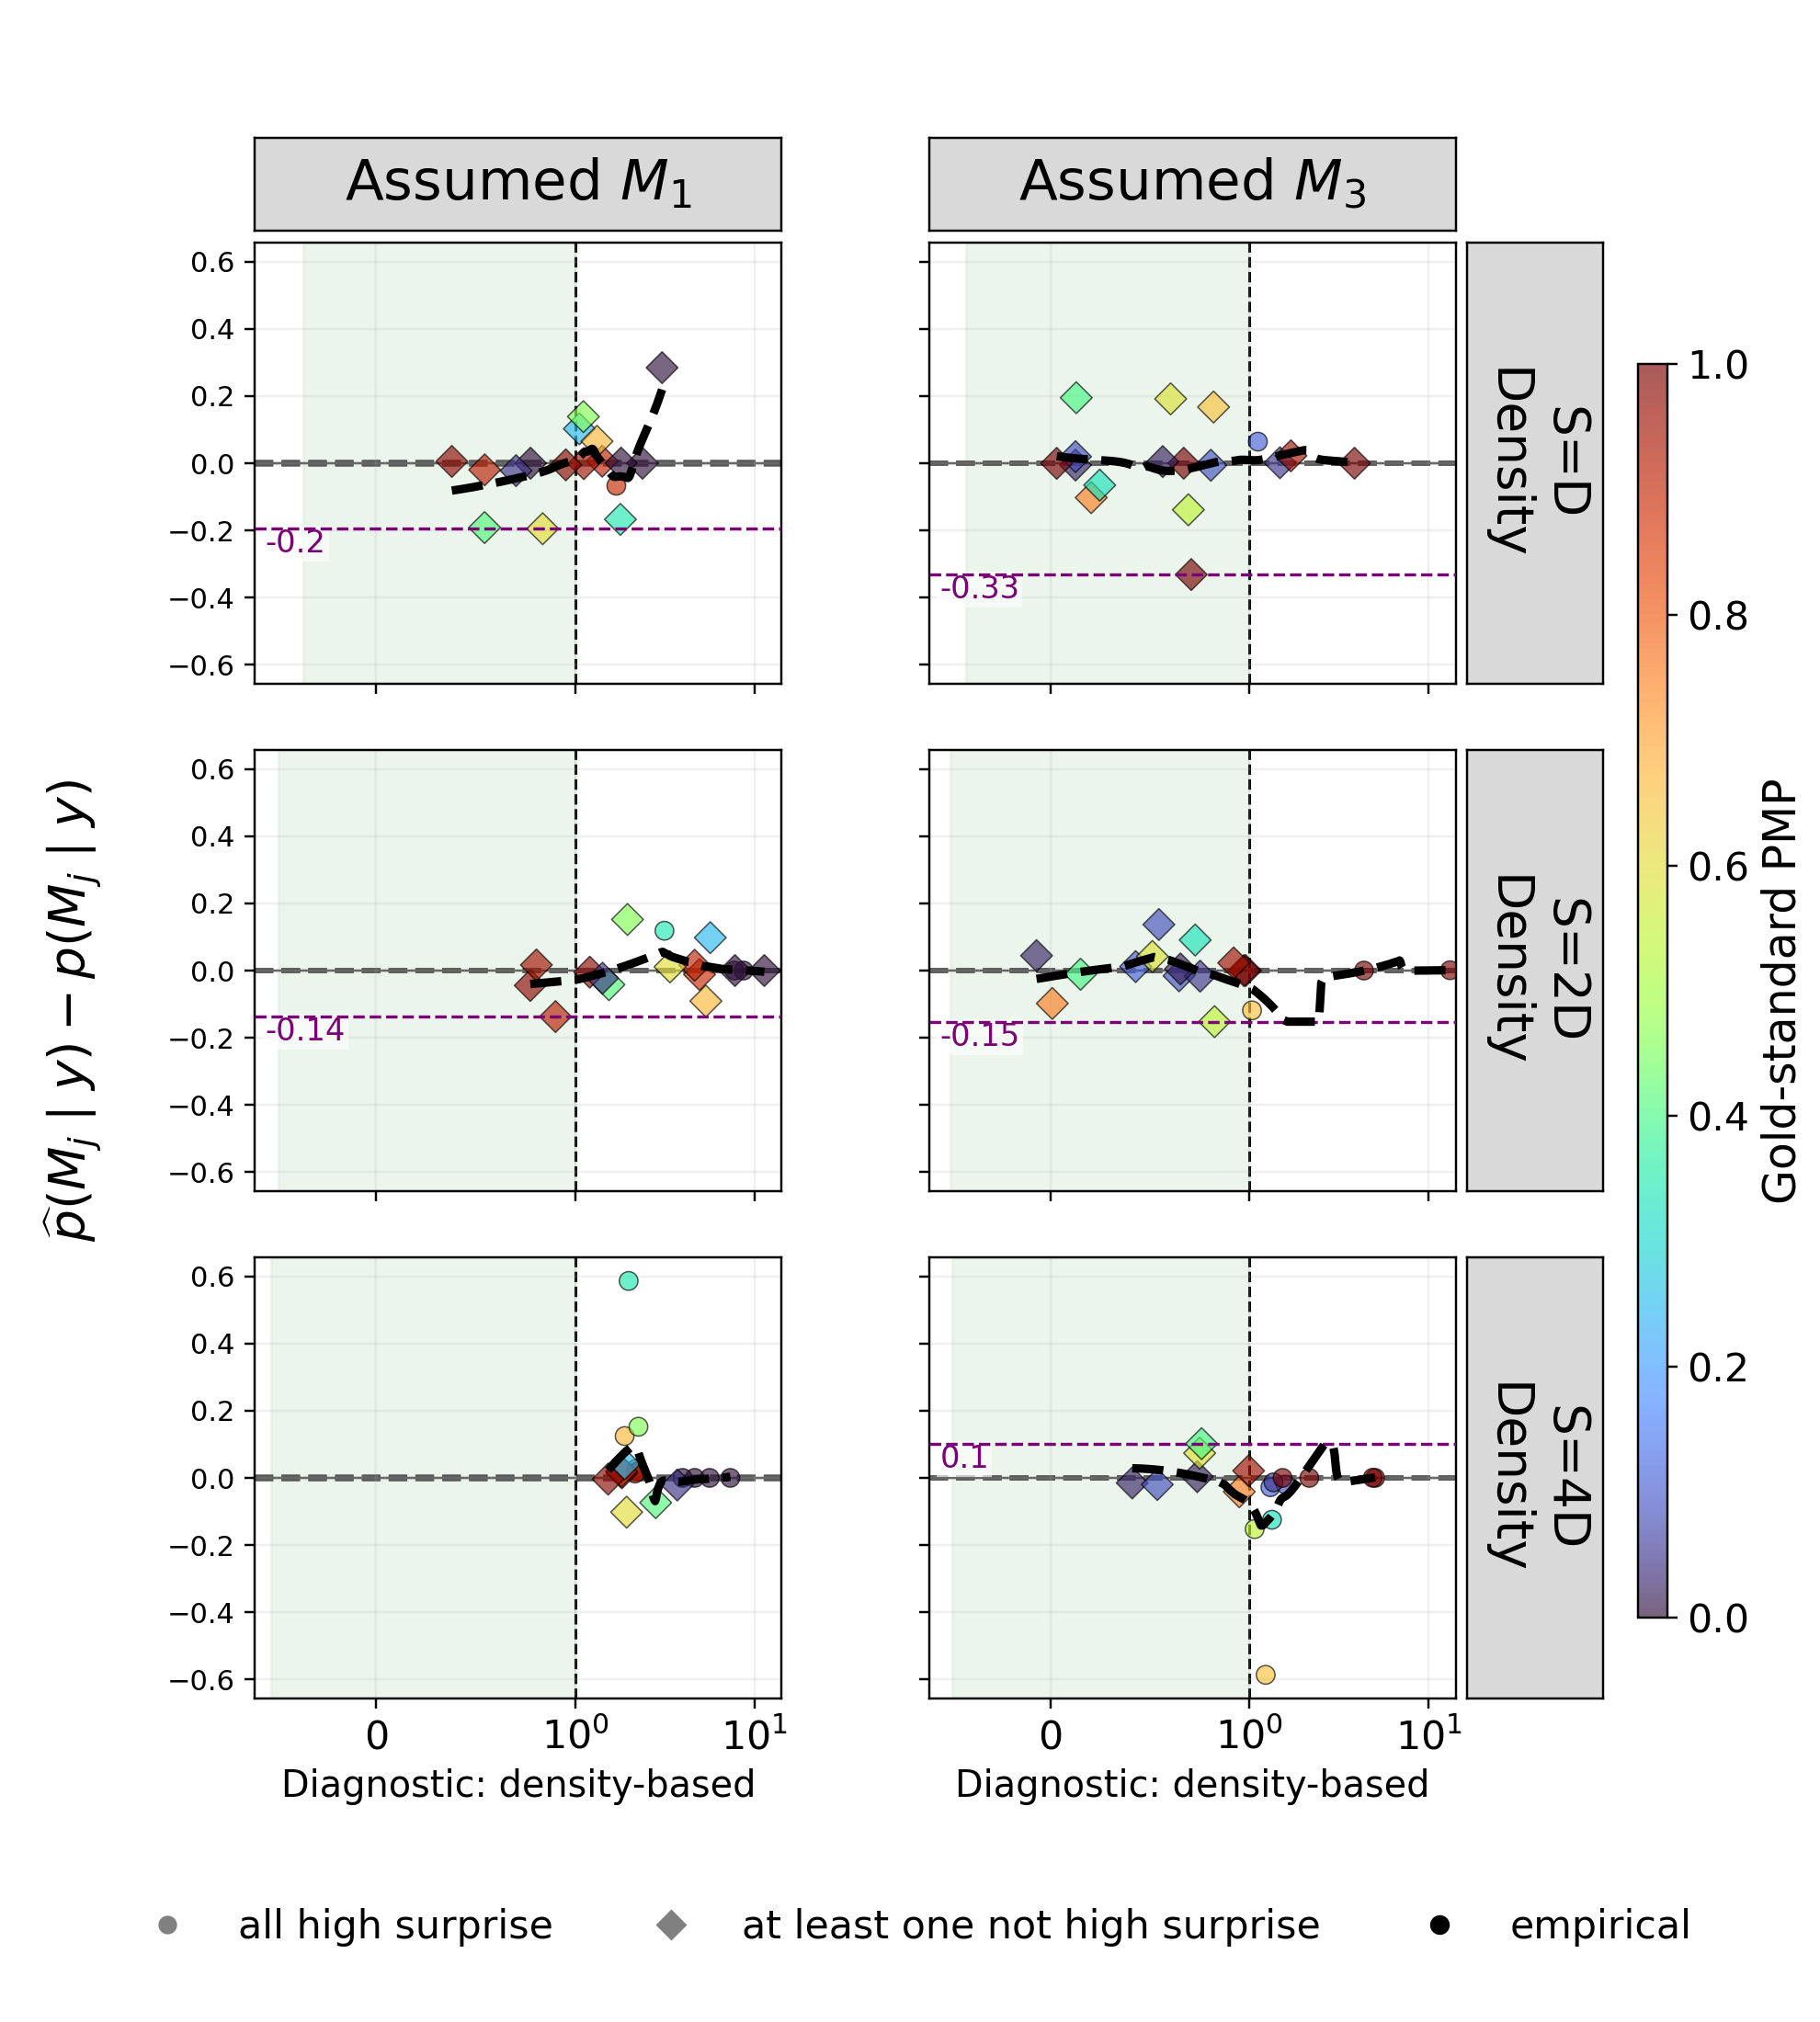

## Empirical PMP error vs. diagnostic $\rho$ — all four assumed models

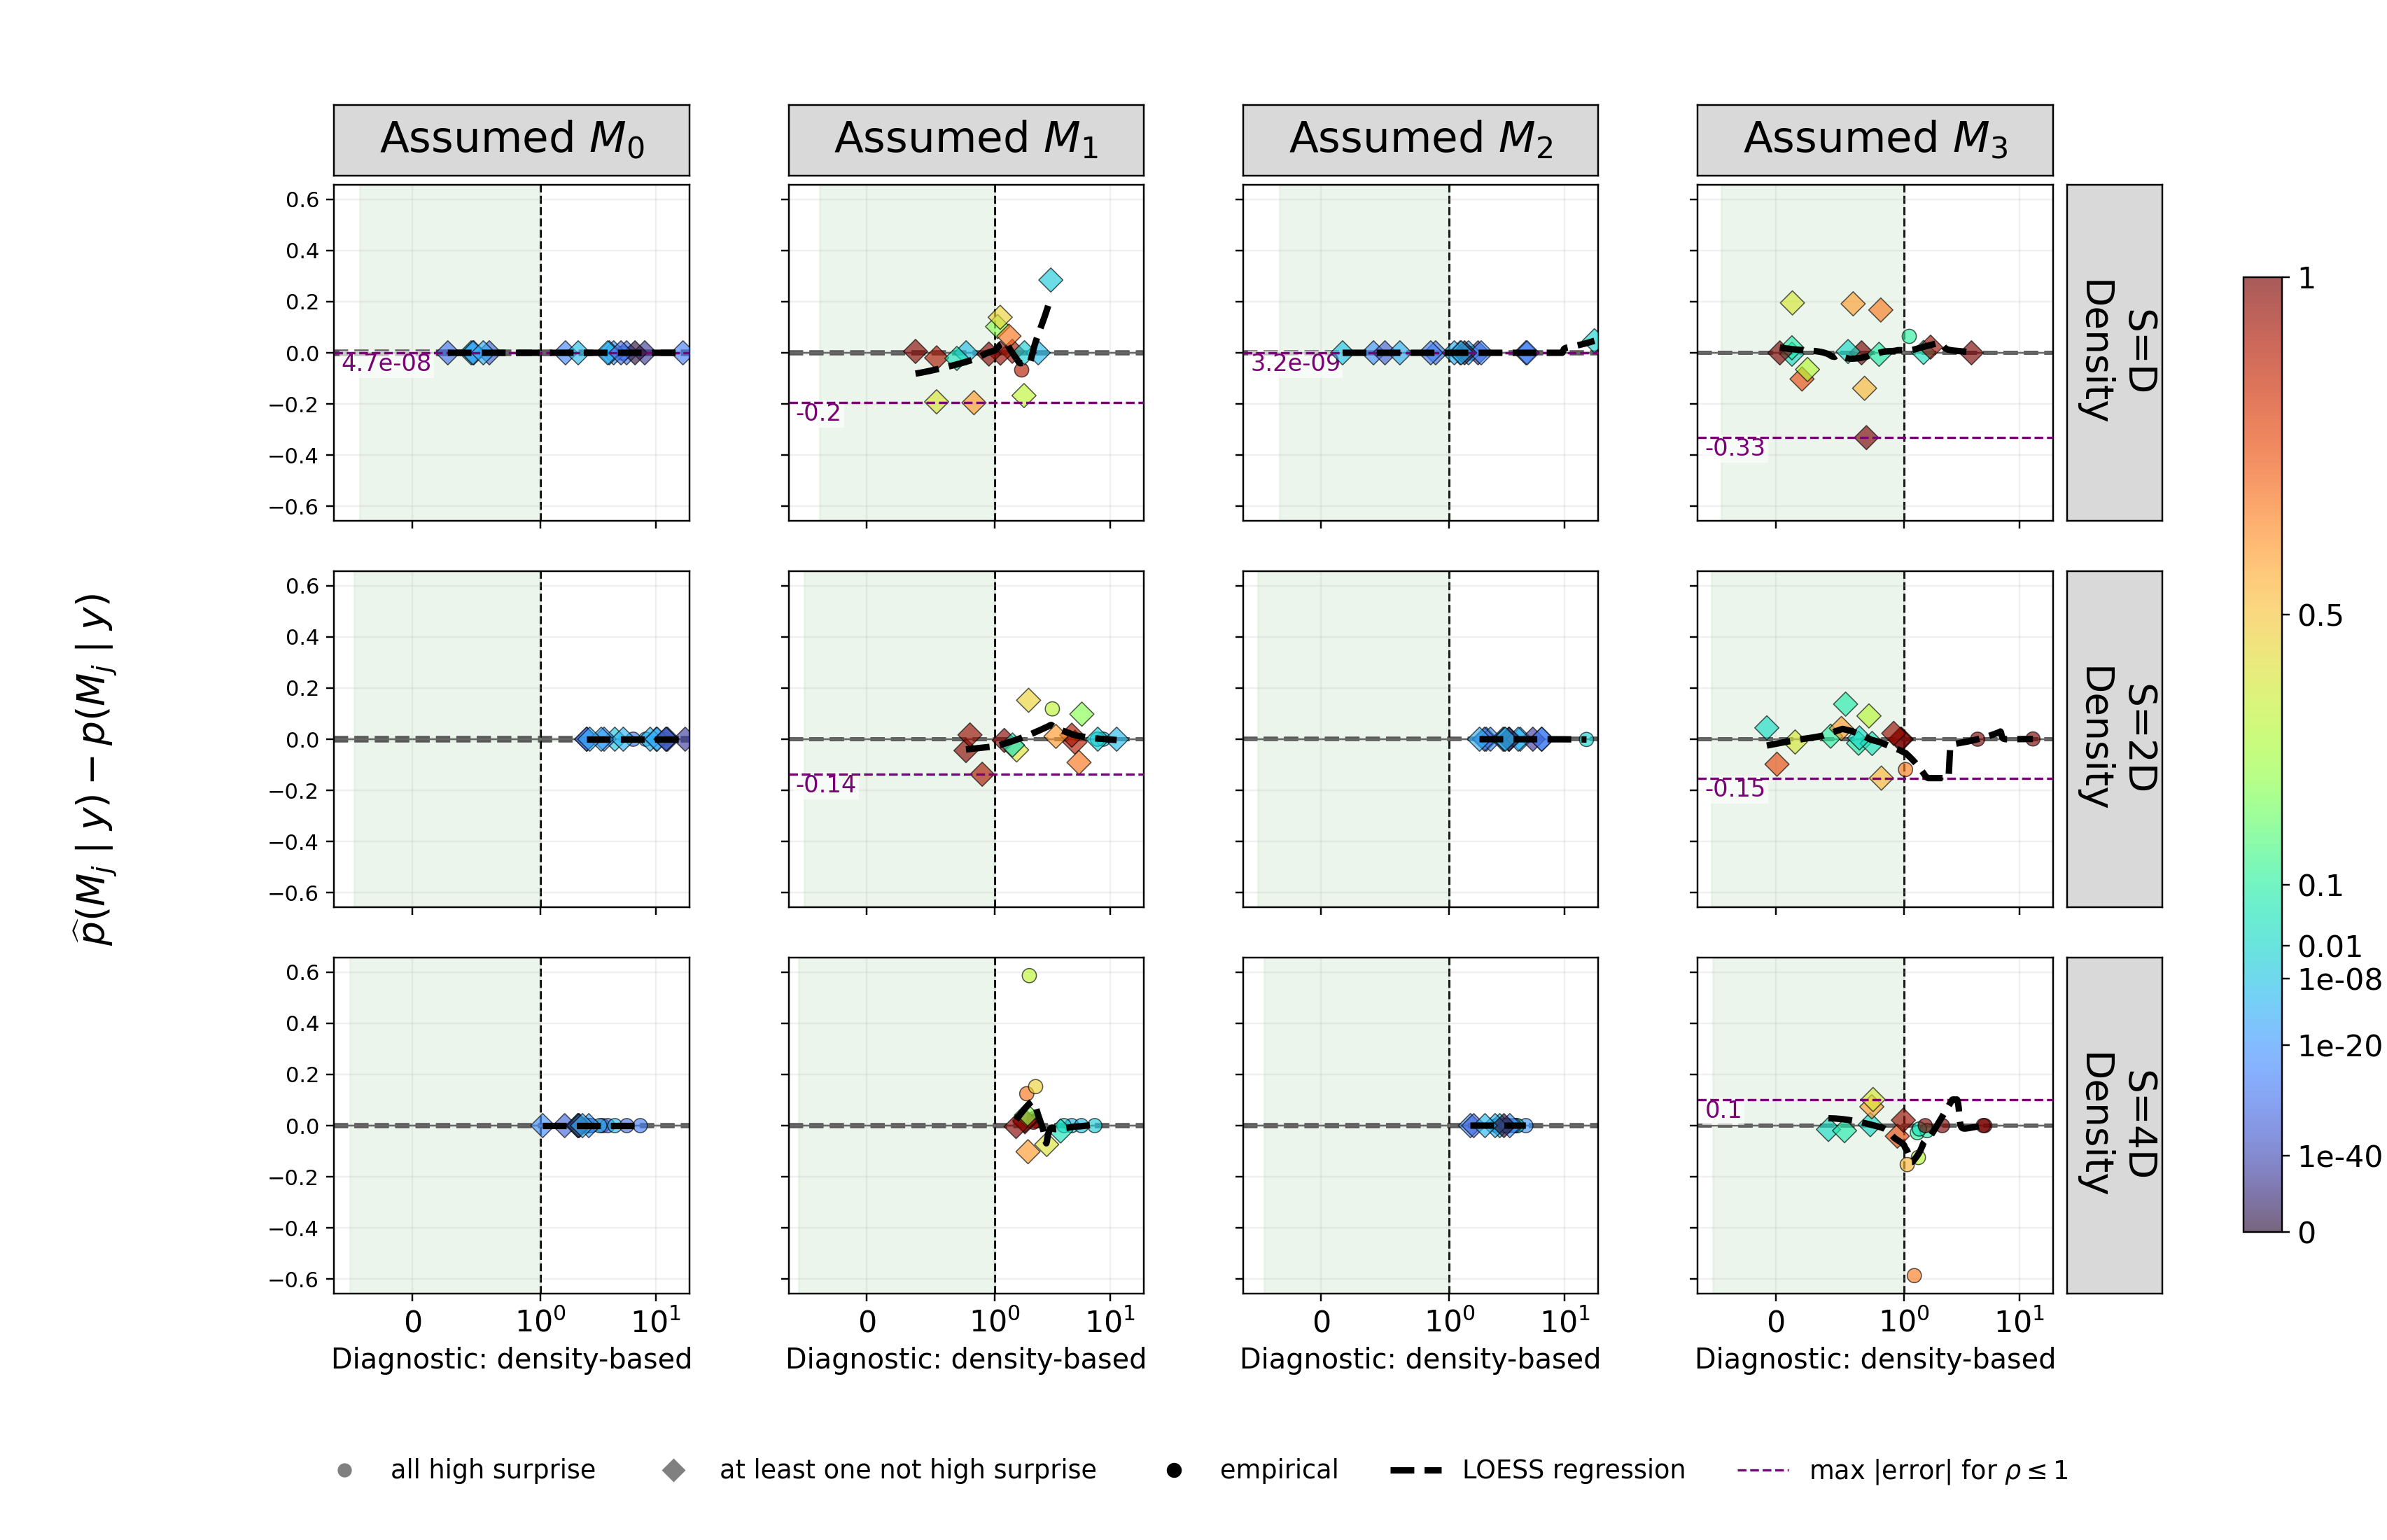

In [4]:
import benchmark.examples.diffusion.results.summary_dimension_comparison as _summary_comparison
from matplotlib.colors import to_rgba as _to_rgba

_EMPIRICAL_FLAG = "_combined_empirical_dataset"
_ORIGINAL_RHO_ERROR_OVERLAY = _summary_comparison.plot_rho_error_overlay


def _plot_empirical_only_overlay(
    data,
    models,
    value,
    path,
    **kwargs,
):
    """Draw only empirical observations and their per-summary medians."""
    empirical_data = data.copy()
    empirical_data[_EMPIRICAL_FLAG] = empirical_data["dataset"].eq("empirical")

    original_scatter = _summary_comparison._scatter_model_matches
    original_handles = _summary_comparison._model_match_handles
    original_summary_handles = _summary_comparison._summary_handles
    original_suptitle = _summary_comparison.plt.Figure.suptitle

    def _empirical_scatter(
        ax, points, x_column, y_column, color, *, alpha, default_size=20
    ):
        empirical_points = points.loc[points[_EMPIRICAL_FLAG]]
        if empirical_points.empty:
            return
        ax.scatter(
            empirical_points[x_column],
            empirical_points[y_column],
            s=60,
            marker="*",
            facecolors=_to_rgba(color, alpha=0.45),
            edgecolors=_to_rgba("black", alpha=0.42),
            linewidths=0.6,
            zorder=2.5,
        )
        median_x = _summary_comparison.pd.to_numeric(
            empirical_points[x_column], errors="coerce"
        ).median()
        median_y = _summary_comparison.pd.to_numeric(
            empirical_points[y_column], errors="coerce"
        ).median()
        if _summary_comparison.np.isfinite(median_x) and (
            _summary_comparison.np.isfinite(median_y)
        ):
            ax.scatter(
                [median_x],
                [median_y],
                s=150,
                marker="*",
                color=color,
                alpha=1.0,
                edgecolors="black",
                linewidths=1.0,
                zorder=5,
            )

    def _empirical_handles(points):
        if not points[_EMPIRICAL_FLAG].any():
            return []
        return [
            _summary_comparison.Line2D(
                [0],
                [0],
                marker="*",
                color="none",
                markerfacecolor=_to_rgba("0.65", alpha=0.45),
                markeredgecolor=_to_rgba("black", alpha=0.42),
                markeredgewidth=0.6,
                markersize=9,
                label="empirical datasets",
            ),
            _summary_comparison.Line2D(
                [0],
                [0],
                marker="*",
                color="none",
                markerfacecolor="0.4",
                markeredgecolor="black",
                markeredgewidth=0.8,
                markersize=12,
                label="empirical median",
            ),
        ]

    def _empirical_summary_handles(
        overlay_order, overlay_colors, *, show_line=True
    ):
        return [
            _summary_comparison.Line2D(
                [0],
                [0],
                marker="*",
                color="none",
                markerfacecolor=overlay_colors[label],
                markeredgecolor="black",
                markeredgewidth=0.7,
                markersize=9,
                label=label,
            )
            for label in overlay_order
        ]

    def _empirical_suptitle(figure, title, *args, **title_kwargs):
        if title == "Empirical dataset":
            title = "Empirical datasets"
        return original_suptitle(figure, title, *args, **title_kwargs)

    _summary_comparison._scatter_model_matches = _empirical_scatter
    _summary_comparison._model_match_handles = _empirical_handles
    _summary_comparison._summary_handles = _empirical_summary_handles
    _summary_comparison.plt.Figure.suptitle = _empirical_suptitle
    try:
        kwargs["show_loess"] = SHOW_EMPIRICAL_ONLY_LOESS
        return _ORIGINAL_RHO_ERROR_OVERLAY(
            empirical_data,
            models,
            value,
            "empirical",
            path,
            **kwargs,
        )
    finally:
        _summary_comparison._scatter_model_matches = original_scatter
        _summary_comparison._model_match_handles = original_handles
        _summary_comparison._summary_handles = original_summary_handles
        _summary_comparison.plt.Figure.suptitle = original_suptitle


def _plot_simulated_and_empirical_overlay(
    data,
    models,
    value,
    source_group,
    path,
    **kwargs,
):
    """Combine both dataset sources while retaining source-specific markers."""
    combined_path = (
        Path(path).parent.parent / "simulated_and_empirical" / Path(path).name
    )
    # The pipeline requests simulated plots first. Reuse those combined files
    # for its subsequent empirical manifest entries instead of drawing twice.
    if source_group == "empirical":
        return _plot_empirical_only_overlay(
            data,
            models,
            value,
            path,
            **kwargs,
        )

    combined_data = data.copy()
    empirical = combined_data["dataset"].eq("empirical")
    combined_data[_EMPIRICAL_FLAG] = empirical
    # The shared plotter's simulated branch keeps every non-"empirical" row.
    combined_data.loc[empirical, "dataset"] = "empirical_in_combined_plot"

    original_scatter = _summary_comparison._scatter_model_matches
    original_handles = _summary_comparison._model_match_handles
    original_legend_layout = _summary_comparison._legend_layout
    original_suptitle = _summary_comparison.plt.Figure.suptitle
    original_lowess = _summary_comparison._lowess_curve
    original_symlog_lowess = _summary_comparison._symlog_lowess_curve
    overlay_column = kwargs.get("overlay_column", "summary")

    def _simulated_only_loess_values(x_values, y_values):
        if INCLUDE_EMPIRICAL_IN_LOESS or x_values.empty:
            return x_values, y_values
        x_column_name = x_values.name
        y_column_name = y_values.name
        if (
            x_column_name not in combined_data.columns
            or y_column_name not in combined_data.columns
        ):
            return x_values, y_values

        context_index = combined_data.index.intersection(x_values.index)
        context = combined_data.loc[context_index]
        if context.empty:
            return x_values, y_values
        context_models = context["model"].dropna().unique()
        context_overlays = context[overlay_column].dropna().unique()
        simulated_only = combined_data.loc[
            ~combined_data[_EMPIRICAL_FLAG]
            & combined_data["model"].isin(context_models)
            & combined_data[overlay_column].isin(context_overlays)
        ].dropna(subset=[x_column_name, y_column_name])
        if value == "logml":
            simulated_only = _summary_comparison._central_interval(
                simulated_only,
                y_column_name,
                ["model", overlay_column],
                _summary_comparison.LOGML_CENTRAL_INTERVAL,
            )
        return (
            simulated_only[x_column_name],
            simulated_only[y_column_name],
        )

    def _combined_lowess(x_values, y_values, *args, **curve_kwargs):
        # The symlog helper calls this again with an unnamed transformed x.
        if x_values.name == "rho":
            x_values, y_values = _simulated_only_loess_values(
                x_values, y_values
            )
        return original_lowess(x_values, y_values, *args, **curve_kwargs)

    def _combined_symlog_lowess(
        x_values, y_values, *args, **curve_kwargs
    ):
        x_values, y_values = _simulated_only_loess_values(
            x_values, y_values
        )
        return original_symlog_lowess(
            x_values, y_values, *args, **curve_kwargs
        )

    def _combined_scatter(
        ax, points, x_column, y_column, color, *, alpha, default_size=20
    ):
        empirical_points = points.loc[points[_EMPIRICAL_FLAG]]
        simulated_points = points.loc[~points[_EMPIRICAL_FLAG]]
        if not simulated_points.empty:
            matched = simulated_points["model_matched"].fillna(False).astype(bool)
            for is_matched, simulated_group in simulated_points.groupby(
                matched, sort=False
            ):
                ax.scatter(
                    simulated_group[x_column],
                    simulated_group[y_column],
                    s=36 if is_matched else default_size,
                    marker="^" if is_matched else "o",
                    facecolors=_to_rgba(
                        color, alpha=0.28 if is_matched else alpha
                    ),
                    edgecolors="none",
                    linewidths=0.0,
                    zorder=2,
                )

            # All seven simulated dataset sources, including each contaminated
            # variant, receive their own median rather than sharing one group.
            source_points = simulated_points.copy()
            source_points["_dataset_source"] = source_points["dataset"].astype(
                "string"
            )
            for _, source_group in source_points.groupby(
                "_dataset_source", observed=True, sort=True
            ):
                source_is_matched = source_group["model_matched"].fillna(
                    False
                ).astype(bool).all()
                median_source_x = _summary_comparison.pd.to_numeric(
                    source_group[x_column], errors="coerce"
                ).median()
                median_source_y = _summary_comparison.pd.to_numeric(
                    source_group[y_column], errors="coerce"
                ).median()
                if _summary_comparison.np.isfinite(median_source_x) and (
                    _summary_comparison.np.isfinite(median_source_y)
                ):
                    ax.scatter(
                        [median_source_x],
                        [median_source_y],
                        s=55,
                        marker="^" if source_is_matched else "o",
                        color=color,
                        alpha=1.0,
                        edgecolors="black",
                        linewidths=0.8,
                        zorder=4,
                    )
        if not empirical_points.empty:
            # Individual empirical observations use pale summary-colored stars.
            ax.scatter(
                empirical_points[x_column],
                empirical_points[y_column],
                s=60,
                marker="*",
                facecolors=_to_rgba(color, alpha=0.45),
                edgecolors=_to_rgba("black", alpha=0.42),
                linewidths=0.6,
                zorder=2.5,
            )
            median_x = _summary_comparison.pd.to_numeric(
                empirical_points[x_column], errors="coerce"
            ).median()
            median_y = _summary_comparison.pd.to_numeric(
                empirical_points[y_column], errors="coerce"
            ).median()
            if _summary_comparison.np.isfinite(median_x) and (
                _summary_comparison.np.isfinite(median_y)
            ):
                # One opaque star per S marks (median diagnostic, median error).
                ax.scatter(
                    [median_x],
                    [median_y],
                    s=150,
                    marker="*",
                    color=color,
                    alpha=1.0,
                    edgecolors="black",
                    linewidths=1.0,
                    zorder=5,
                )

    def _combined_handles(points):
        handles = [
            _summary_comparison.Line2D(
                [0],
                [0],
                marker="o",
                color="none",
                markerfacecolor=_to_rgba("0.4", alpha=0.5),
                markeredgecolor="none",
                markersize=6,
                label="other simulated datasets",
            ),
            _summary_comparison.Line2D(
                [0],
                [0],
                marker="^",
                color="none",
                markerfacecolor=_to_rgba("0.4", alpha=0.28),
                markeredgecolor="none",
                markersize=7,
                label="well-specified datasets",
            ),
            _summary_comparison.Line2D(
                [0],
                [0],
                marker="o",
                color="none",
                markerfacecolor="0.4",
                markeredgecolor="black",
                markeredgewidth=0.8,
                markersize=7,
                label="other simulated median",
            ),
            _summary_comparison.Line2D(
                [0],
                [0],
                marker="^",
                color="none",
                markerfacecolor="0.4",
                markeredgecolor="black",
                markeredgewidth=0.8,
                markersize=7,
                label="well-specified median",
            ),
        ]
        if points[_EMPIRICAL_FLAG].any():
            handles.append(
                _summary_comparison.Line2D(
                    [0],
                    [0],
                    marker="*",
                    color="none",
                    markerfacecolor=_to_rgba("0.65", alpha=0.45),
                    markeredgecolor=_to_rgba("black", alpha=0.42),
                    markeredgewidth=0.6,
                    markersize=9,
                    label="empirical datasets",
                )
            )
            handles.append(
                _summary_comparison.Line2D(
                    [0],
                    [0],
                    marker="*",
                    color="none",
                    markerfacecolor="0.4",
                    markeredgecolor="black",
                    markeredgewidth=0.8,
                    markersize=12,
                    label="empirical median",
                )
            )
        return handles

    def _combined_legend_layout(handles, *, summary_count, model_count):
        if model_count == 4:
            return handles, len(handles), 1
        if model_count == 2:
            return handles, 5, 2
        return original_legend_layout(
            handles, summary_count=summary_count, model_count=model_count
        )

    def _combined_suptitle(figure, title, *args, **kwargs):
        if title == "Simulated datasets":
            title = "Simulated and empirical datasets"
        return original_suptitle(figure, title, *args, **kwargs)

    _summary_comparison._scatter_model_matches = _combined_scatter
    _summary_comparison._model_match_handles = _combined_handles
    _summary_comparison._legend_layout = _combined_legend_layout
    _summary_comparison.plt.Figure.suptitle = _combined_suptitle
    _summary_comparison._lowess_curve = _combined_lowess
    _summary_comparison._symlog_lowess_curve = _combined_symlog_lowess
    try:
        # Empirical points remain visible even when the fit uses simulations only.
        kwargs["show_loess"] = SHOW_LOESS
        loess_fit_key = (
            "simulated_and_empirical"
            if INCLUDE_EMPIRICAL_IN_LOESS
            else "simulated_only"
        )
        kwargs["loess_frac"] = LOESS_FRAC_BY_FIT_SOURCE[loess_fit_key]
        return _ORIGINAL_RHO_ERROR_OVERLAY(
            combined_data,
            models,
            value,
            "simulated",
            combined_path,
            **kwargs,
        )
    finally:
        _summary_comparison._scatter_model_matches = original_scatter
        _summary_comparison._model_match_handles = original_handles
        _summary_comparison._legend_layout = original_legend_layout
        _summary_comparison.plt.Figure.suptitle = original_suptitle
        _summary_comparison._lowess_curve = original_lowess
        _summary_comparison._symlog_lowess_curve = original_symlog_lowess


def _run_combined_calibrated_comparison_pipeline(**kwargs):
    original_plotter = _summary_comparison.plot_rho_error_overlay
    _summary_comparison.plot_rho_error_overlay = (
        _plot_simulated_and_empirical_overlay
    )
    try:
        combined_comparisons = run_calibrated_comparison_pipeline(**kwargs)
    finally:
        _summary_comparison.plot_rho_error_overlay = original_plotter

    for comparison in combined_comparisons.values():
        manifest = comparison["manifest"].drop_duplicates(
            subset=["path"]
        ).copy()
        manifest["source_group"] = manifest["source_group"].replace(
            {
                "simulated": "simulated and empirical",
                "empirical": "empirical only",
            }
        )
        comparison["manifest"] = manifest
    return combined_comparisons


if SHOW_LOESS:
    loess_fit_key = (
        "simulated_and_empirical"
        if INCLUDE_EMPIRICAL_IN_LOESS
        else "simulated_only"
    )
    loess_fit_label = loess_fit_key.replace("_and_", " + ").replace(
        "_", " "
    )
    print(
        "LOESS lines: shown; "
        f"fit source: {loess_fit_label}; "
        f"frac: {LOESS_FRAC_BY_FIT_SOURCE[loess_fit_key]}"
    )
else:
    print("LOESS lines: hidden")


comparisons = _run_combined_calibrated_comparison_pipeline(
    metrics=METRICS,
    model_sets=MODEL_SETS,
    summary_specs=RERUN_SUMMARY_SPECS,
    output_root=OUTPUT_ROOT,
    xscale=XSCALE,
    yscale=YSCALE,
    y_symlog_linthresh=LOGML_Y_SYMLOG_LINTHRESH,
    normalize_metrics=NORMALIZE_METRICS,
    threshold_path=THRESHOLD_PATH,
)

for name, comparison in comparisons.items():
    print(name, comparison["output_root"])
    display_summary_dimension_comparison(comparison)

gold_pmp_paths = generate_calibrated_gold_pmp_lowess_grid(
    METRICS[0],
    output_root=OVERLAY_OUTPUT_ROOT,
    xscale=XSCALE,
    yscale=YSCALE,
    normalize_metrics=NORMALIZE_METRICS,
    threshold_path=THRESHOLD_PATH,
    summary_specs=RERUN_SUMMARY_SPECS,
    output_variant=RERUN_VARIANT,
)
display_gold_pmp_lowess_grid(gold_pmp_paths)

all_model_gold_pmp_paths = generate_calibrated_gold_pmp_lowess_grid(
    METRICS[0],
    output_root=OVERLAY_OUTPUT_ROOT,
    xscale=XSCALE,
    yscale=YSCALE,
    normalize_metrics=NORMALIZE_METRICS,
    threshold_path=THRESHOLD_PATH,
    summary_specs=RERUN_SUMMARY_SPECS,
    output_variant=RERUN_VARIANT,
    models=MODEL_SETS["all"],
)
display_gold_pmp_lowess_grid(
    all_model_gold_pmp_paths,
    width=1200,
    models=MODEL_SETS["all"],
)
